In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import os

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [6]:
train = ImageDataGenerator(rescale=1/255)
validation = ImageDataGenerator(rescale=1/255)

In [10]:
BASE_DIR = os.path.abspath(os.path.join('..', 'Dataset'))
CLASSES = ['Bear', 'Cat', 'Cow', 'Dog', 'Horse']

set = train.flow_from_directory(os.path.join(BASE_DIR, 'train'),
                                           target_size=(200, 200),
                                           classes=CLASSES,
                                           batch_size= 10,
                                           class_mode='categorical')

validation_dataset = validation.flow_from_directory(os.path.join(BASE_DIR, 'validation'),
                                           target_size=(200, 200),
                                           classes=CLASSES,
                                           batch_size= 10,
                                           class_mode='categorical')

Found 501 images belonging to 5 classes.
Found 50 images belonging to 5 classes.


In [12]:
model = tf.keras.models.Sequential([tf.keras.layers.Input(shape=(200,200,3)),
                                    tf.keras.layers.Conv2D(16,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    
                                    tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(512, activation='relu'),
                                    tf.keras.layers.Dense(len(CLASSES), activation='softmax')
                                    
                                   ])

In [14]:
model.compile(loss='categorical_crossentropy',
              optimizer= 'adam',
              metrics=['accuracy'])

In [ ]:
model_fit = model.fit(set,
                      validation_data = validation_dataset,
                      epochs = 10,
                      callbacks=[tf.keras.callbacks.CSVLogger('history.csv')])
loss, accuracy = model.evaluate(validation_dataset)
print(f"Validation accuracy: {round(accuracy * 100, 2)}%")

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.4711 - loss: 1.4613 - val_accuracy: 0.9200 - val_loss: 0.4000
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.7904 - loss: 0.5058 - val_accuracy: 0.8800 - val_loss: 0.2865
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.8922 - loss: 0.3144 - val_accuracy: 0.9200 - val_loss: 0.2126
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9381 - loss: 0.1990 - val_accuracy: 0.9400 - val_loss: 0.1205
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.9581 - loss: 0.0958 - val_accuracy: 0.9600 - val_loss: 0.1018
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.9721 - loss: 0.0920 - val_accuracy: 1.0000 - val_loss: 0.0217
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.9920 - loss: 0.0384 - val_accuracy: 1.0000 - val_loss: 0.0471
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step - accuracy: 0.9940 - loss: 0.0222 - val_accuracy: 1.

In [37]:
model_fit = model.fit(set,
                      validation_data = validation_dataset,
                      epochs = 50,
                      callbacks=[tf.keras.callbacks.CSVLogger('history.csv')])
loss, accuracy = model.evaluate(validation_dataset)
print(f"Validation accuracy: {round(accuracy * 100, 2)}%")

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 406ms/step - accuracy: 1.0000 - loss: 3.9217e-04 - val_accuracy: 1.0000 - val_loss: 3.4168e-04
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 1.0000 - loss: 1.5234e-04 - val_accuracy: 1.0000 - val_loss: 2.8325e-04
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 1.0000 - loss: 9.5368e-05 - val_accuracy: 1.0000 - val_loss: 1.3314e-04
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 1.0000 - loss: 7.2312e-05 - val_accuracy: 1.0000 - val_loss: 9.0644e-05
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step - accuracy: 1.0000 - loss: 4.7287e-05 - val_accuracy: 1.0000 - val_loss: 6.6746e-05
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 1.0000 - loss: 3.7270e-05 - val_accuracy: 1.0000 - val_loss: 4.8124e-05
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - accuracy: 1.0000 - loss: 3.0723e-05 - val_accuracy: 1.0000 - val_loss: 4.6332e-05
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/

In [16]:
his = pd.read_csv('history.csv') 
his.head(10)

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.471058,1.461261,0.92,0.399978
1,1,0.790419,0.505767,0.88,0.286512
2,2,0.892216,0.314413,0.92,0.212561
3,3,0.938124,0.198996,0.94,0.120497
4,4,0.958084,0.095837,0.96,0.101821
5,5,0.972056,0.092039,1.00,0.021736
6,6,0.992016,0.038414,1.00,0.047054
7,7,0.994012,0.022240,1.00,0.005727
8,8,1.000000,0.002474,1.00,0.003064
9,9,1.000000,0.000726,1.00,0.000924


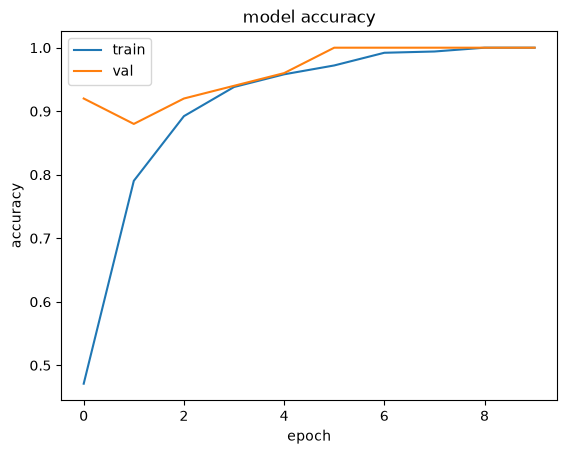

In [17]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

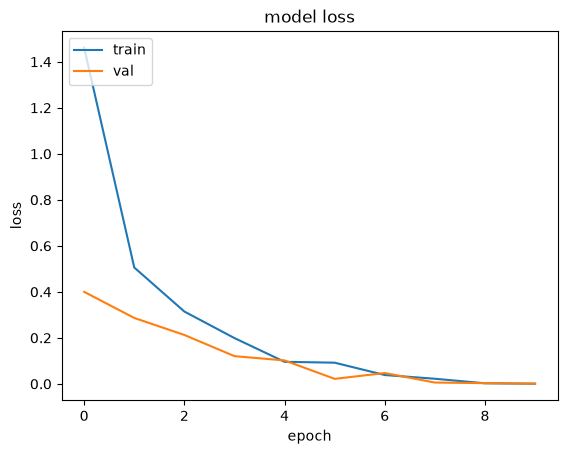

In [18]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [24]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter( y=model_fit.history['val_loss'], name="val_loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['loss'], name="loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['val_accuracy'], name="val_accuracy"),
    secondary_y=True)

fig.add_trace(
    go.Scatter( y=model_fit.history['accuracy'], name="accuracy"),
    secondary_y=True)

# Add figure title
fig.update_layout(
    title_text="Loss/Accuracy of Conv2D Model")

# Set x-axis title
fig.update_xaxes(title_text="Number of Epochs")

# Set y-axes titles
fig.update_yaxes(title_text="<b>primary</b> Loss", secondary_y=False)
fig.update_yaxes(title_text="<b>secondary</b> Accuracy", secondary_y=True)

fig.show()


NameError: name 'make_subplots' is not defined

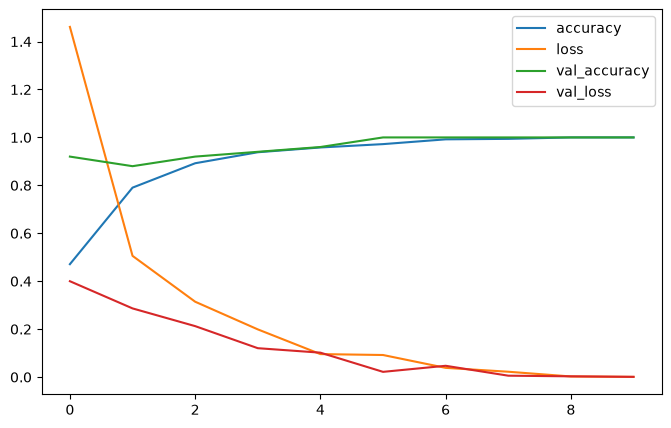

In [20]:
pd.DataFrame(model_fit.history).plot(figsize=(8,5))
plt.show()

In [25]:
model.summary() #Detail of model

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,082,801 (198.68 MB)

 Trainable params: 17,360,933 (66.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,721,868 (132.45 MB)

In [29]:
plot_model(model, to_file='convlstm_model_structure_plot.png', show_shapes=True, show_layer_names=True)

NameError: name 'plot_model' is not defined

In [30]:
# Check models first to see if file exists already.
# If not, the model is saved to disk.
if os.path.isfile('models/CNN_predict_model.h5') is False:
    model.save('models/CNN_predict_model.h5')

In [31]:
validation_dataset.class_indices

{'Bear': 0, 'Cat': 1, 'Cow': 2, 'Dog': 3, 'Horse': 4}

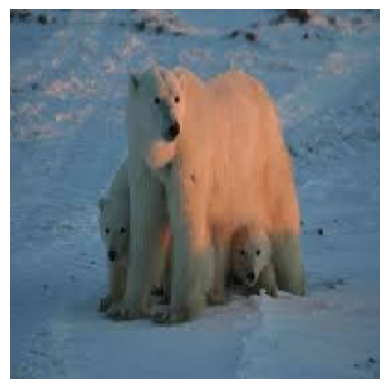

This is a Bear (99.58%)


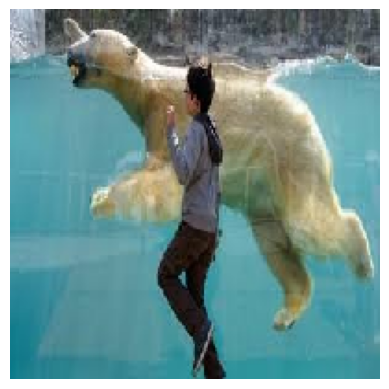

This is a Bear (100.00%)


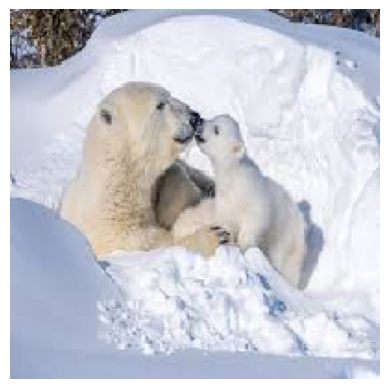

This is a Bear (99.99%)


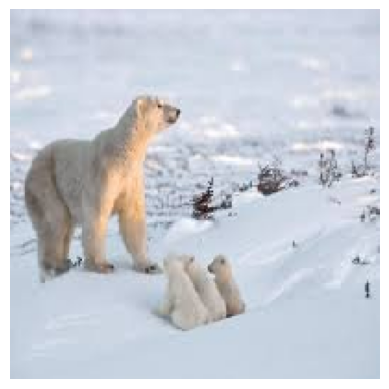

This is a Bear (100.00%)


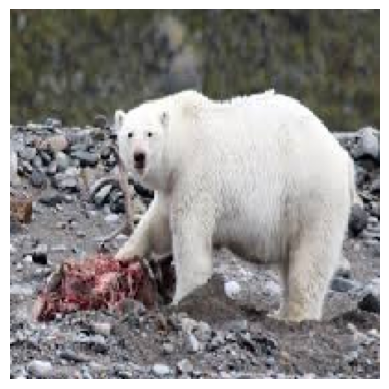

This is a Bear (100.00%)


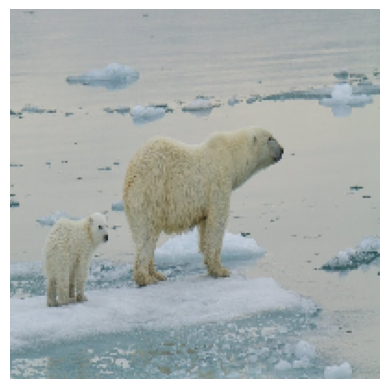

This is a Bear (99.97%)


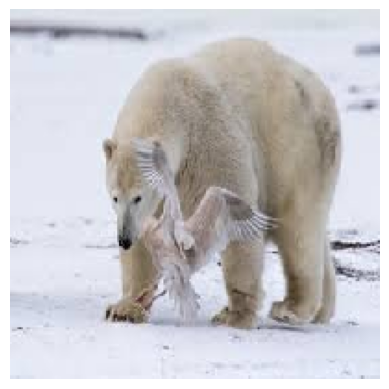

This is a Bear (99.99%)


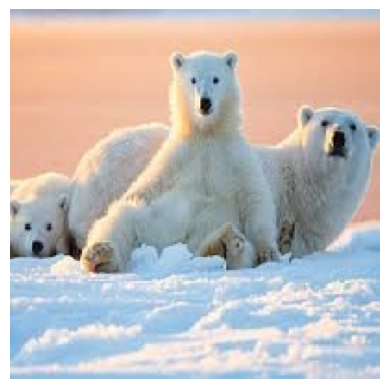

This is a Bear (100.00%)


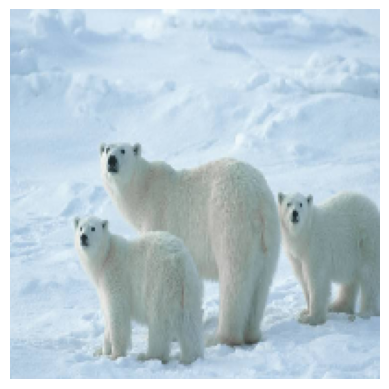

This is a Bear (100.00%)


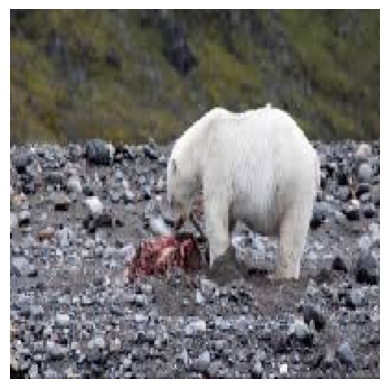

This is a Bear (100.00%)


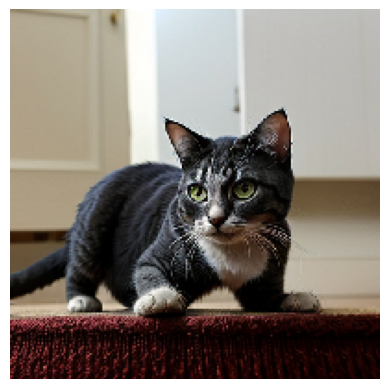

This is a Cat (100.00%)


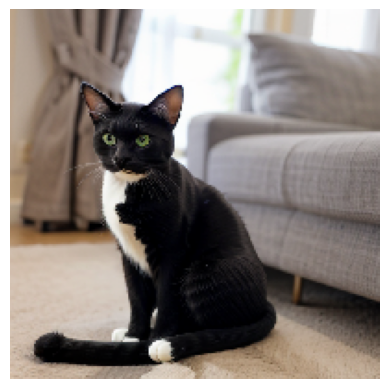

This is a Cat (100.00%)


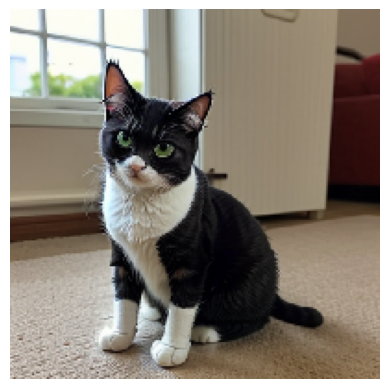

This is a Cat (99.98%)


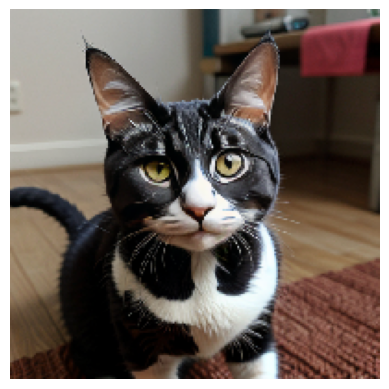

This is a Cat (100.00%)


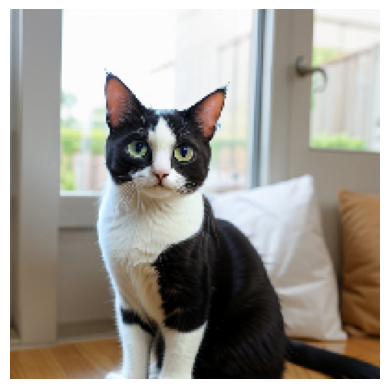

This is a Cat (99.99%)


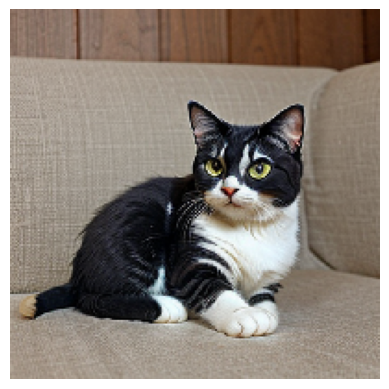

This is a Cat (99.98%)


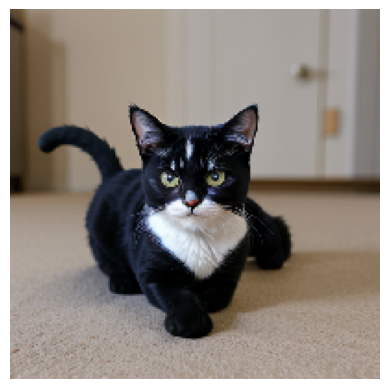

This is a Cat (99.95%)


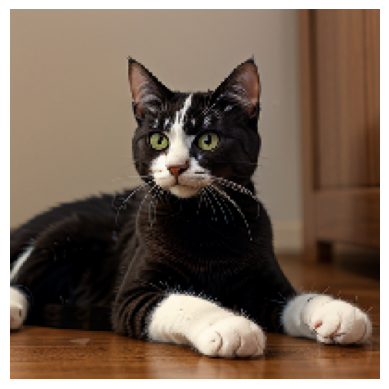

This is a Cat (100.00%)


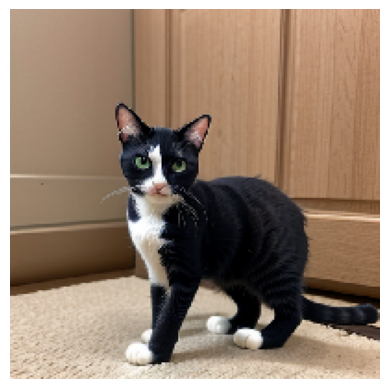

This is a Cat (100.00%)


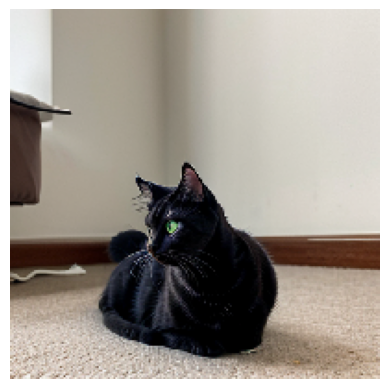

This is a Cat (99.99%)


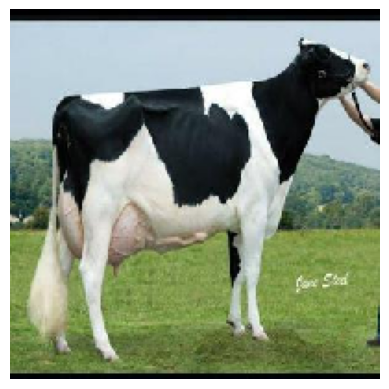

This is a Cow (100.00%)


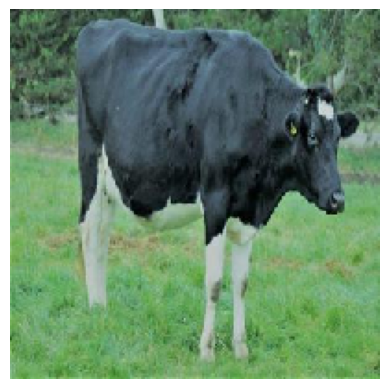

This is a Cow (100.00%)


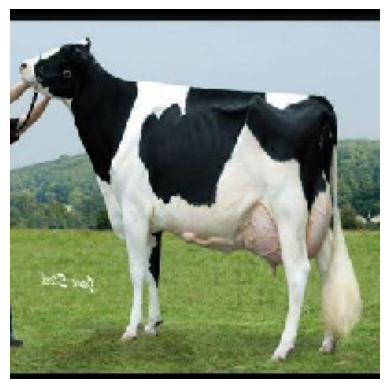

This is a Cow (100.00%)


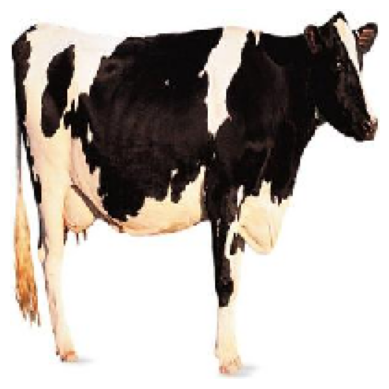

This is a Cow (100.00%)


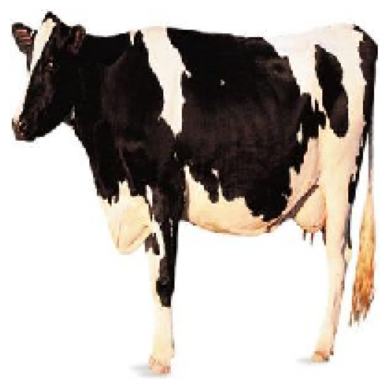

This is a Cow (100.00%)


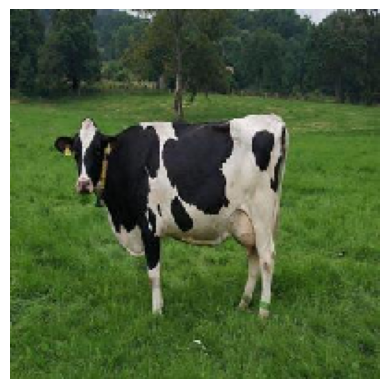

This is a Cow (100.00%)


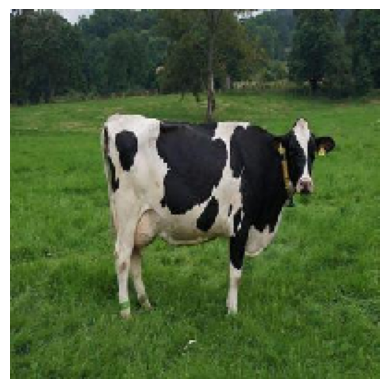

This is a Cow (100.00%)


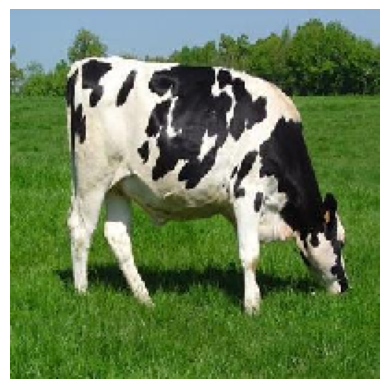

This is a Cow (100.00%)


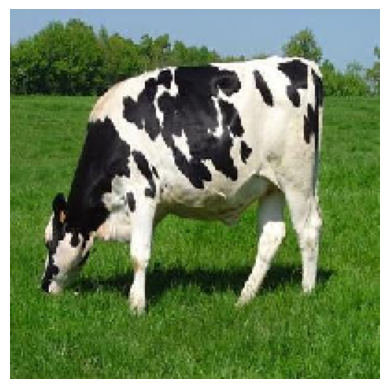

This is a Cow (100.00%)


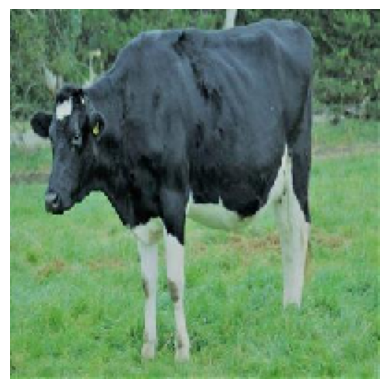

This is a Cow (100.00%)


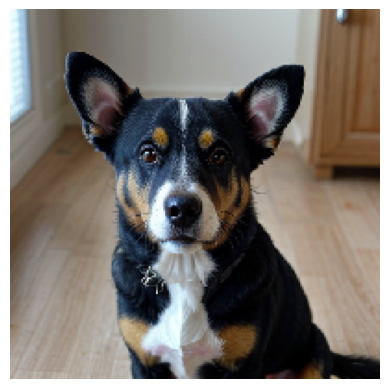

This is a Dog (99.95%)


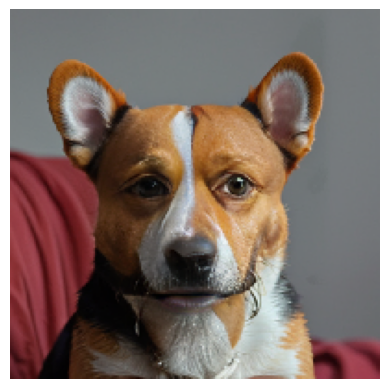

This is a Dog (99.75%)


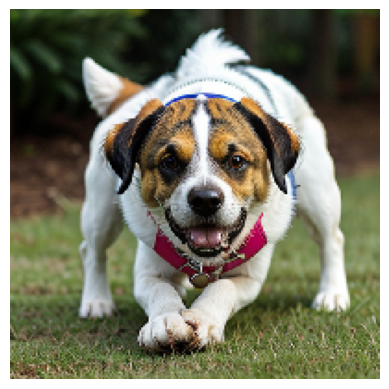

This is a Dog (100.00%)


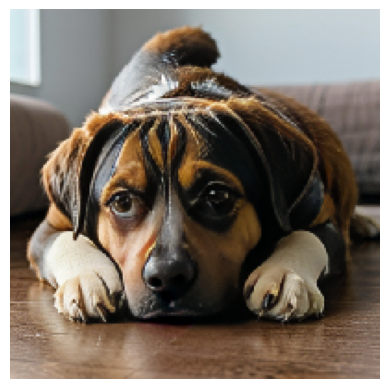

This is a Dog (99.96%)


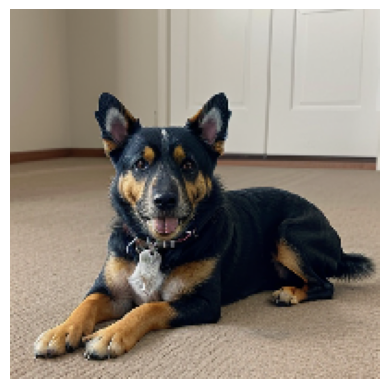

This is a Dog (99.73%)


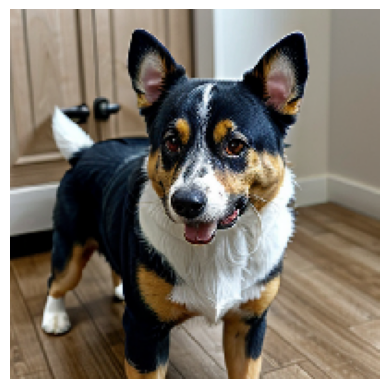

This is a Dog (100.00%)


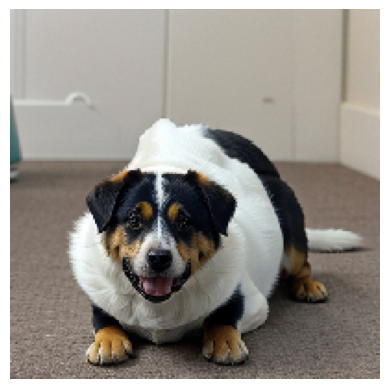

This is a Dog (99.27%)


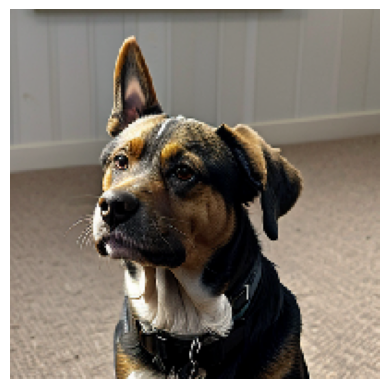

This is a Dog (99.94%)


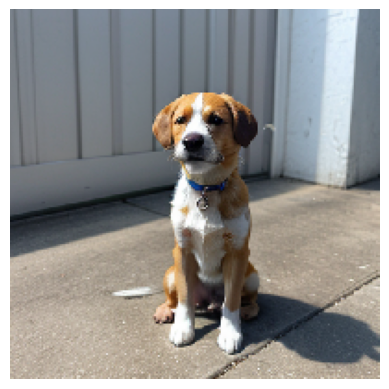

This is a Dog (99.52%)


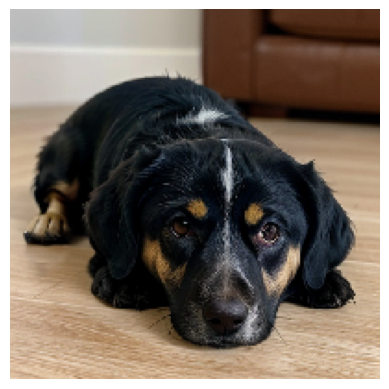

This is a Dog (99.99%)


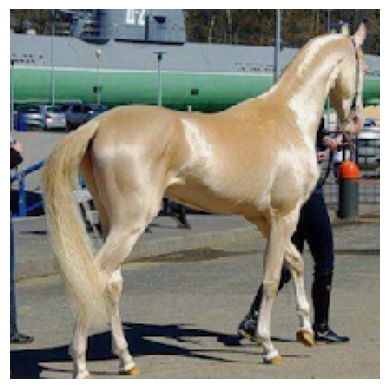

This is a Horse (100.00%)


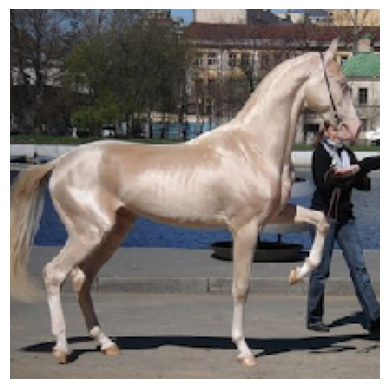

This is a Horse (100.00%)


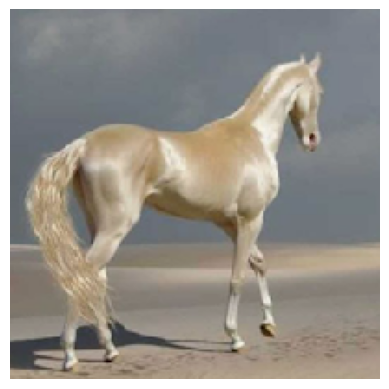

This is a Horse (99.39%)


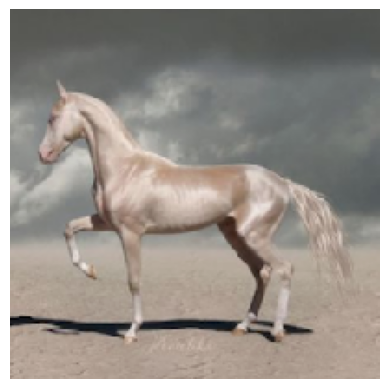

This is a Horse (98.58%)


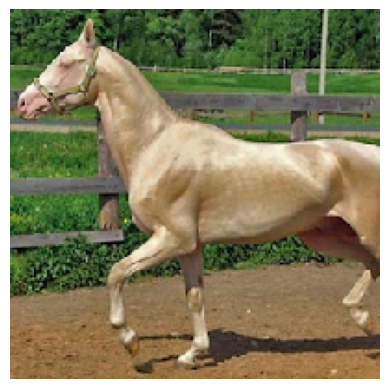

This is a Horse (100.00%)


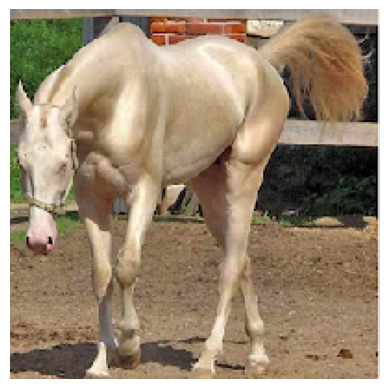

This is a Horse (99.99%)


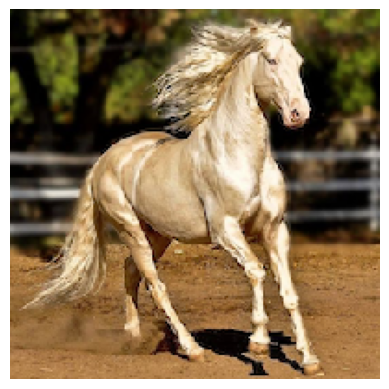

This is a Horse (100.00%)


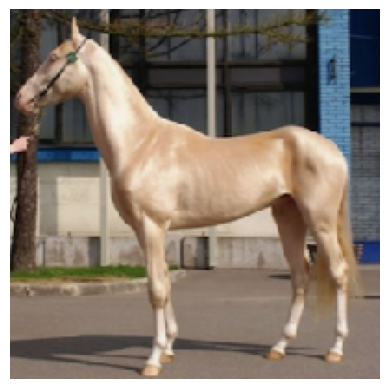

This is a Horse (100.00%)


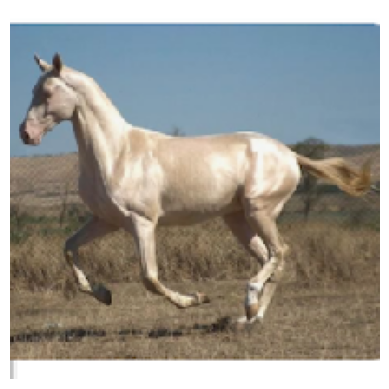

This is a Horse (99.93%)


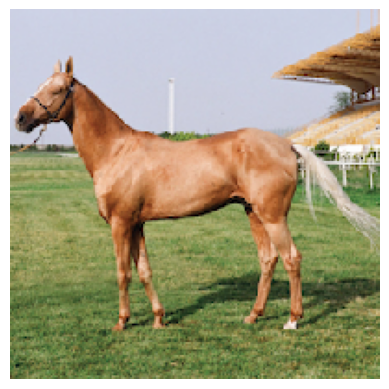

This is a Horse (99.99%)


In [32]:
dir_path = os.path.join(BASE_DIR, 'testing')  # path of images that you want to test

for root, _, files in os.walk(dir_path):
    for i in files:
        img = image.load_img(os.path.join(root, i), target_size=(200, 200))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        
        X = image.img_to_array(img)
        X = X / 255.0
        X = np.expand_dims(X, axis=0)
        val = model.predict(X, verbose=0)
        
        class_index = np.argmax(val[0])
        confidence = val[0][class_index] * 100
        picture = CLASSES[class_index]
        
        print(f"This is a {picture} ({confidence:.2f}%)")

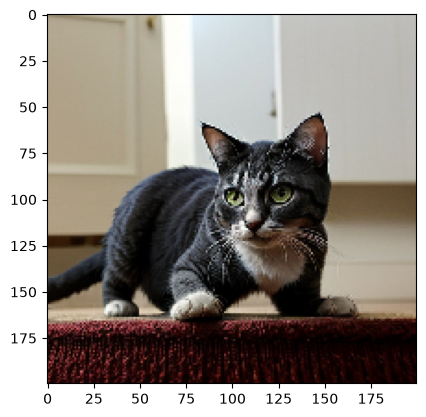

In [34]:
img = image.load_img(os.path.join(BASE_DIR, 'train', 'Cat', '0 (1).png'), target_size=(200, 200))
plt.imshow(img)

In [36]:
img = cv2.imread(os.path.join(BASE_DIR, 'train', 'Cat', '0 (1).png'))  # cv2 returns None if the path is wrong or the file is not an image
assert img is not None, os.path.join(BASE_DIR, 'train', 'Cat', '0 (1).png')
img.shape  #height, width, and channels of image

(512, 512, 3)